In [84]:
import pandas as pd 
import numpy as np 

In [85]:
df=pd.read_csv (r"C:\Users\chakr\Downloads\archive\train_test_network.csv")

In [86]:
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [56]:
df.isnull().sum()

src_ip                    0
src_port                  0
dst_ip                    0
dst_port                  0
proto                     0
service                   0
duration                  0
src_bytes                 0
dst_bytes                 0
conn_state                0
missed_bytes              0
src_pkts                  0
src_ip_bytes              0
dst_pkts                  0
dst_ip_bytes              0
dns_query                 0
dns_qclass                0
dns_qtype                 0
dns_rcode                 0
dns_AA                    0
dns_RD                    0
dns_RA                    0
dns_rejected              0
ssl_version               0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_version              0
http_request_body_len     0
http_response_body_len    0
http_status_code    

In [87]:
df.replace("-",np.NaN, inplace= True)

In [108]:
df= df.drop(['ssl_version','ssl_cipher','ssl_resumed','ssl_established',
'ssl_subject','ssl_issuer',
'http_trans_depth','http_method','http_uri','http_version',
'http_user_agent','http_orig_mime_types','http_resp_mime_types',
'weird_name','weird_addl','weird_notice'] ,axis=1)

In [110]:
df.duplicated().sum()

27502

In [111]:
df = df.drop_duplicates()

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183541 entries, 0 to 211042
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_port                183541 non-null  int64  
 1   dst_port                183541 non-null  int64  
 2   proto                   183541 non-null  object 
 3   service                 77773 non-null   object 
 4   duration                183541 non-null  float64
 5   src_bytes               183541 non-null  int64  
 6   dst_bytes               183541 non-null  int64  
 7   conn_state              183541 non-null  object 
 8   missed_bytes            183541 non-null  int64  
 9   src_pkts                183541 non-null  int64  
 10  src_ip_bytes            183541 non-null  int64  
 11  dst_pkts                183541 non-null  int64  
 12  dst_ip_bytes            183541 non-null  int64  
 13  dns_qclass              183541 non-null  int64  
 14  dns_qtype               1

In [116]:
df.describe()

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,183541.000000,183541.000000,183541.000000,1.835410e+05,1.835410e+05,1.835410e+05,183541.000000,1.835410e+05,183541.000000,1.835410e+05,183541.000000,183541.000000,183541.000000,183541.000000,1.835410e+05,183541.000000,183541.000000
mean,40574.864014,2145.581265,8.853257,2.967894e+05,2.975834e+05,3.959123e+04,10.917032,8.773521e+02,4.384214,1.820273e+03,261.019064,4.064389,0.142568,0.075220,1.665114e+02,0.339635,0.771571
std,18051.401200,6982.155235,604.924790,1.833067e+07,1.932871e+07,5.642054e+06,98.345039,2.390739e+04,354.614918,2.039298e+05,2911.958416,25.400291,0.640036,9.911729,3.267574e+04,8.756576,0.419821
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,36174.000000,53.000000,0.000015,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,46060.000000,80.000000,0.000523,0.000000e+00,0.000000e+00,0.000000e+00,2.000000,1.120000e+02,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,52222.000000,445.000000,0.163834,1.300000e+02,1.880000e+02,0.000000e+00,5.000000,4.230000e+02,2.000000,2.400000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000


In [117]:
 for col in df.columns:
    print(col)

src_port
dst_port
proto
service
duration
src_bytes
dst_bytes
conn_state
missed_bytes
src_pkts
src_ip_bytes
dst_pkts
dst_ip_bytes
dns_qclass
dns_qtype
dns_rcode
dns_AA
dns_RD
dns_RA
dns_rejected
http_request_body_len
http_response_body_len
http_status_code
label
type


In [118]:
df['label'] = df['label'].apply(lambda x: 0 if str(x).lower() == 'normal' else 1)

In [121]:
 df['label'].value_counts(dropna=False)

label
1    183541
Name: count, dtype: int64

In [120]:
df['label'].unique()

array([1], dtype=int64)

In [95]:
df['type'].unique()

array(['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal',
       'password', 'ransomware', 'scanning', 'xss'], dtype=object)

In [130]:
 df['label'].value_counts()

label
1    141615
0     41926
Name: count, dtype: int64

In [129]:
df['label'] = df['type'].apply(lambda x: 0 if str(x).strip().lower() == 'normal' else 1)

In [132]:
df['label'].iloc[81000:90000]

94619     0
94620     0
94621     0
94622     0
94623     0
         ..
104079    0
104080    0
104081    0
104082    0
104083    0
Name: label, Length: 9000, dtype: int64

In [131]:
 df[df['label'] == 0].head()

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,http_request_body_len,http_response_body_len,http_status_code,label,type
81043,47260,15600,udp,NaN,0.000000,0,0,S0,0,1,...,0,NaN,NaN,NaN,NaN,0,0,0,0,normal
81044,1880,51782,tcp,NaN,0.000000,0,0,OTH,0,0,...,0,NaN,NaN,NaN,NaN,0,0,0,0,normal
81045,34296,10502,tcp,NaN,0.000000,0,0,OTH,0,0,...,0,NaN,NaN,NaN,NaN,0,0,0,0,normal
81046,46608,53,udp,dns,0.000549,0,298,SHR,0,0,...,0,NaN,NaN,NaN,NaN,0,0,0,0,normal
81049,33269,15600,udp,NaN,0.000000,0,0,S0,0,1,...,0,NaN,NaN,NaN,NaN,0,0,0,0,normal


In [134]:
X = df.drop(['label','type'], axis=1)
y = df['label']

In [135]:
len(df.columns)

25

In [136]:
 df.columns

Index(['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes',
       'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
       'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode',
       'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'label', 'type'],
      dtype='object')

In [137]:
X = df.drop(['label','type'], axis=1)

In [138]:
X = pd.get_dummies(X, columns=[
    'proto',
    'service',
    'conn_state',
    'dns_AA',
    'dns_RD',
    'dns_RA',
    'dns_rejected'
])

In [140]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [141]:
X.dtypes


src_port                    int64
dst_port                    int64
duration                  float64
src_bytes                   int64
dst_bytes                   int64
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
http_request_body_len       int64
http_response_body_len      int64
http_status_code            int64
proto_icmp                   bool
proto_tcp                    bool
proto_udp                    bool
service_dce_rpc              bool
service_dns                  bool
service_ftp                  bool
service_gssapi               bool
service_http                 bool
service_smb                  bool
service_smb;gssapi           bool
service_ssl                  bool
conn_state_OTH               bool
conn_state_REJ               bool
conn_state_RST

In [142]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(X_scaled)

In [143]:
len(X.columns)

48

In [144]:
 print(X_selected.shape)


(183541, 48)


In [145]:
 from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_selected)

In [146]:
df['cluster'] = clusters

In [147]:
pd.crosstab(df['cluster'], df['label'])

label,0,1
cluster,,
0,40465,141615
1,1461,0


In [148]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_selected, clusters)
print(score)

0.5265077932459394


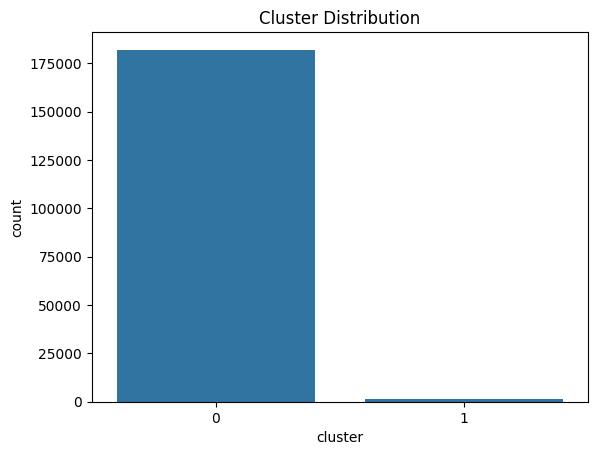

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['cluster'])
plt.title("Cluster Distribution")
plt.show()

In [ ]:
print(kmeans.cluster_centers_)

In [149]:
print(X_selected.shape)

(183541, 48)
